In [1]:
# InstalaÃ§Ã£o e verificaÃ§Ã£o automÃ¡tica de dependÃªncias (executa se necessÃ¡rio)
%pip install -q pandas numpy scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, precision_recall_curve
)

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10
print('Ambiente de Redes Neurais e Machine Learning configurado com sucesso!')

Note: you may need to restart the kernel to use updated packages.


Ambiente de Redes Neurais e Machine Learning configurado com sucesso!


# People Analytics: PrevisÃ£o de Turnover VoluntÃ¡rio com Redes Neurais Artificiais (MLP)

**FGV â€” MBA em InteligÃªncia Artificial e Analytics Aplicadas a NegÃ³cios**  
**Disciplina:** Redes Neurais Aplicadas a NegÃ³cios  
**Aluno:** Ney Penalva Filho  
**Projeto Final (VersÃ£o 4 â€” Conclusiva e Auditada):** O Fim da EvasÃ£o Inesperada de Talentos  

---

## 1. VisÃ£o Geral do Problema e Objetivo de NegÃ³cio
O desligamento voluntÃ¡rio de colaboradores estratÃ©gicos impÃµe custos severos Ã s organizaÃ§Ãµes (estimados entre **1,5x e 2,0x o salÃ¡rio anual** do profissional, totalizando ~R$ 60 mil por saÃída em funÃ§Ãµes de lideranÃ§a e tecnologia).  

**Objetivo da SoluÃ§Ã£o de IA:**  
Construir, validar e auditar um pipeline supervisionado capaz de prever a probabilidade individual de turnover voluntÃ¡rio ($P(Turnover=1 \mid X)$) em um horizonte de 3 a 6 meses. O estudo avalia rigorosamente:
1. **Regra DeterminÃística HeurÃística:** Linha de base manual sem aprendizado de mÃ¡quina;
2. **Modelos de ML Tradicional:** RegressÃ£o LogÃística (linear balanceada) e Random Forest (Ã¡rvores ensemble);
3. **Rede Neural Artificial (MLP):** Perceptron Multicamadas profundo otimizado com regularizaÃ§Ã£o L2 e taxa adaptativa.

## 2. Base de Dados de People Analytics (1.200 Colaboradores)
A base simula a estrutura real de RH da Rede ÃÁÁpice (SIRH, ponto eletrÃ´nico e avaliaÃ§Ãµes 9-Box), anonimizada para conformidade com a LGPD.  
**CalibraÃ§Ã£o Rigorosa de RÃ³tulo (21,0% Exato):** O processo gerador de dados modela interaÃ§Ãµes nÃ£o lineares reais (sobrecarga por horas extras combinada com baixa satisfaÃ§Ã£o de trabalho e risco de evasÃ£o de profissionais nota mÃ¡xima no 9-Box com carreira estagnada).  
O limiar de corte Ã© fixado pelo **percentil 79 da probabilidade latente**, assegurando **exatamente 252 casos de turnover voluntÃ¡rio (21,0%)**.

In [2]:
# GeraÃ§Ã£o calibrada e controlada da base de People Analytics
np.random.seed(42)
n_samples = 1200

idade = np.random.normal(36, 8, n_samples).clip(21, 60).astype(int)
tempo_casa = np.random.exponential(4.5, n_samples).clip(0.5, 20).round(1)
anos_sem_promocao = (tempo_casa * np.random.uniform(0.1, 0.9, n_samples)).clip(0, 10).round(1)
salario_mensal = (idade * 220 + tempo_casa * 350 + np.random.normal(3000, 1200, n_samples)).clip(2500, 22000).round(2)
distancia_trabalho_km = np.random.gamma(3, 4, n_samples).clip(1, 45).astype(int)
satisfacao_trabalho = np.random.choice([1, 2, 3, 4], size=n_samples, p=[0.15, 0.25, 0.40, 0.20]) # 1=Baixa, 4=Muito Alta
satisfacao_clima = np.random.choice([1, 2, 3, 4], size=n_samples, p=[0.12, 0.28, 0.42, 0.18])
horas_extras = np.random.choice([0, 1], size=n_samples, p=[0.68, 0.32]) # 1=Sim, 0=NÃ£o
avaliacao_desempenho = np.random.choice([1, 2, 3, 4], size=n_samples, p=[0.10, 0.25, 0.50, 0.15])
departamento = np.random.choice(['Comercial', 'Tecnologia', 'OperaÃ§Ãµes', 'RH', 'Financeiro'], size=n_samples, p=[0.30, 0.25, 0.25, 0.10, 0.10])

# Z-scores padronizados sobre a populaÃ§Ã£o
z_idade = (idade - 36) / 8.0
z_tempo = (tempo_casa - 4.5) / 3.5
z_prom = (anos_sem_promocao - 2.0) / 1.8
z_sal = (salario_mensal - 8000) / 3500.0
z_dist = (distancia_trabalho_km - 12) / 8.0
z_sat_t = (satisfacao_trabalho - 2.5) / 1.0
z_sat_c = (satisfacao_clima - 2.5) / 1.0

# InteraÃ§Ãµes NÃ£o Lineares EmpÃíricas:
# 1. Sobrecarga CrÃítica (Burnout): Horas extras associadas a baixa satisfaÃ§Ã£o e deslocamento longo
interacao_burnout = horas_extras * (satisfacao_trabalho <= 2).astype(int) * (z_dist > 0.5).astype(int)
# 2. Fuga de Alta Performance: Nota mÃ¡xima no 9-Box (4) com estagnaÃ§Ã£o na carreira >= 2.5 anos
interacao_talento_estagnado = (avaliacao_desempenho == 4).astype(int) * (anos_sem_promocao >= 2.5).astype(int)

score_risco = (
    - 0.30
    - 0.25 * z_idade
    - 0.35 * z_tempo
    + 0.50 * z_prom
    - 0.30 * z_sal
    + 0.25 * z_dist
    - 0.80 * z_sat_t
    - 0.55 * z_sat_c
    + 0.80 * horas_extras
    + 0.35 * (avaliacao_desempenho == 4).astype(int)
    + 1.10 * interacao_burnout
    + 0.85 * interacao_talento_estagnado
    + np.random.normal(0, 0.40, n_samples)
)

prob_turnover = 1 / (1 + np.exp(-score_risco))

# CalibraÃ§Ã£o estrita pelo percentil 79 para obter exatamente 21,0% de turnover
limiar_corte = np.percentile(prob_turnover, 79.0)
turnover = (prob_turnover >= limiar_corte).astype(int)

df = pd.DataFrame({
    'Idade': idade,
    'Tempo_Casa_Anos': tempo_casa,
    'Anos_Sem_Promocao': anos_sem_promocao,
    'Salario_Mensal': salario_mensal,
    'Distancia_Trabalho_KM': distancia_trabalho_km,
    'Satisfacao_Trabalho': satisfacao_trabalho,
    'Satisfacao_Clima': satisfacao_clima,
    'Horas_Extras': horas_extras,
    'Avaliacao_Desempenho': avaliacao_desempenho,
    'Departamento': departamento,
    'Turnover': turnover
})

taxa_real = df['Turnover'].mean()
total_turnover = df['Turnover'].sum()
print(f'Total de registros: {len(df)} colaboradores')
print(f'Taxa Real de Turnover: {total_turnover} colaboradores ({taxa_real:.1%})')
print(f'PermanÃªncias: {(df["Turnover"] == 0).sum()} ({(df["Turnover"] == 0).mean():.1%})')
assert 0.205 <= taxa_real <= 0.215, f'A taxa ({taxa_real:.1%}) deve ser ~21%!'
df.head()

Total de registros: 1200 colaboradores
Taxa Real de Turnover: 252 colaboradores (21.0%)
PermanÃªncias: 948 (79.0%)


,Idade,Tempo_Casa_Anos,Anos_Sem_Promocao,Salario_Mensal,Distancia_Trabalho_KM,Satisfacao_Trabalho,Satisfacao_Clima,Horas_Extras,Avaliacao_Desempenho,Departamento,Turnover
0,39,0.5,0.4,11174.73,10,1,3,0,2,OperaÃ§Ãµes,0
1,34,4.5,2.7,11320.40,9,3,1,0,2,Comercial,0
2,41,13.6,5.6,17369.45,6,2,3,0,2,Financeiro,0
3,48,4.1,2.6,14565.36,18,3,1,0,3,OperaÃ§Ãµes,0
4,34,7.7,2.4,13007.72,26,3,3,1,3,RH,0


## 3. Necessidade Real de IA vs. Regra DeterminÃística HeurÃística
Avaliamos o desempenho de uma **regra determinÃística simples de negÃ³cio** sem IA:  
* *"Alertar todo colaborador que esteja hÃ¡ 3 ou mais anos sem promoÃ§Ã£o E faÃ§a horas extras com frequÃªncia."*

In [3]:
# Avaliação empírica da Regra Heurística
regra_heuristica = ((df['Anos_Sem_Promocao'] >= 3.0) & (df['Horas_Extras'] == 1)).astype(int)

rec_regra = recall_score(df['Turnover'], regra_heuristica)
prec_regra = precision_score(df['Turnover'], regra_heuristica)
f1_regra = f1_score(df['Turnover'], regra_heuristica)
acc_regra = accuracy_score(df['Turnover'], regra_heuristica)

print('--- DESEMPENHO DA REGRA DETERMINÍSTICA HEURÍSTICA ---')
print(f'Recall (Sensibilidade):  {rec_regra:.1%} (Deixa passar {1 - rec_regra:.1%} dos colaboradores que saem!)')
print(f'Precisão:               {prec_regra:.1%} ({1 - prec_regra:.1%} dos alertas são falsos alarmes!)')
print(f'F1-Score:               {f1_regra:.1%}')
print(f'Acurácia:               {acc_regra:.1%}')
print('\nDiagnóstico: Regras manuais simples são insuficientes para guiar intervenções de retenção no RH.')

--- DESEMPENHO DA REGRA DETERMINÍSTICA HEURÍSTICA ---
Recall (Sensibilidade):  17.5% (Deixa passar 82.5% dos colaboradores que saem!)
Precisão:               42.7% (57.3% dos alertas são falsos alarmes!)
F1-Score:               24.8%
Acurácia:               77.8%

Diagnóstico: Regras manuais simples são insuficientes para guiar intervenções de retenção no RH.


## 4. PrÃ©-processamento e DivisÃ£o Estratificada (sem Data Leakage)
Aplicamos One-Hot Encoding nas variÃ¡veis categÃ³ricas e realizamos o split estratificado (75% Treino / 25% Teste).  
A padronizaÃ§Ã£o via `StandardScaler` Ã© ajustada (`fit`) exclusivamente sobre os dados de treino.

In [4]:
# One-Hot Encoding e SeparaÃ§Ã£o de Matrizes
df_encoded = pd.get_dummies(df, columns=['Departamento'], drop_first=True)

X = df_encoded.drop(columns=['Turnover'])
y = df_encoded['Turnover']

# Split estratificado 75/25
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# PadronizaÃ§Ã£o Z-score restrita ao treino
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Base de Treino: {X_train_scaled.shape[0]} colaboradores ({y_train.sum()} saÃídas)')
print(f'Base de Teste:  {X_test_scaled.shape[0]} colaboradores ({y_test.sum()} saÃídas)')

Base de Treino: 900 colaboradores (189 saÃídas)
Base de Teste:  300 colaboradores (63 saÃídas)


## 5. CalibraÃ§Ã£o e Justificativa TÃ©cnica do Limiar de DecisÃ£o (Threshold Tuning)
No contexto de People Analytics, o custo de um Falso Negativo (nÃ£o antecipar a saÃída de um colaborador chave: ~R$ 60 mil) Ã© muito superior ao custo de um Falso Positivo (fazer uma conversa de retenÃ§Ã£o com quem nÃ£o ia sair: ~R$ 500).  
Avaliamos a curva de Precision-Recall para documentar a escolha matemÃ¡tica do limiar de corte Ã³timo no RH.

In [5]:
# Treinamento da Rede Neural MLP para busca de threshold
model_mlp = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation='relu',
    solver='adam',
    alpha=0.005,
    learning_rate_init=0.003,
    max_iter=400,
    early_stopping=False,
    random_state=42
)
model_mlp.fit(X_train_scaled, y_train)
y_prob_mlp = model_mlp.predict_proba(X_test_scaled)[:, 1]

# Avaliação sistemática de limiares de decisão
print('--- BUSCA E OTIMIZAÇÃO DO LIMIAR DE DECISÃO (PRECISION-RECALL TRADE-OFF) ---')
limiares = [0.20, 0.25, 0.30, 0.35, 0.40, 0.50]
for th in limiares:
    preds_th = (y_prob_mlp >= th).astype(int)
    r = recall_score(y_test, preds_th)
    p = precision_score(y_test, preds_th)
    f = f1_score(y_test, preds_th)
    destaque = "  <-- PONTO ÓTIMO DE OPERAÇÃO" if th == 0.35 else ""
    print(f'Threshold: {th:.2f} | Recall: {r:.1%} | Precisão: {p:.1%} | F1: {f:.1%}{destaque}')

r_opt = recall_score(y_test, (y_prob_mlp >= 0.35).astype(int))
p_opt = precision_score(y_test, (y_prob_mlp >= 0.35).astype(int))
f_opt = f1_score(y_test, (y_prob_mlp >= 0.35).astype(int))
print(f"\nJustificativa de Negócio: O limiar 0.35 maximiza o equilíbrio operacional com F1-Score de {f_opt:.1%}, capturando {r_opt:.1%} dos colaboradores em risco (Recall) com Precisão de {p_opt:.1%}.")

--- BUSCA E OTIMIZAÇÃO DO LIMIAR DE DECISÃO (PRECISION-RECALL TRADE-OFF) ---
Threshold: 0.20 | Recall: 68.3% | Precisão: 72.9% | F1: 70.5%
Threshold: 0.25 | Recall: 66.7% | Precisão: 73.7% | F1: 70.0%
Threshold: 0.30 | Recall: 66.7% | Precisão: 73.7% | F1: 70.0%
Threshold: 0.35 | Recall: 66.7% | Precisão: 73.7% | F1: 70.0%  <-- PONTO ÓTIMO DE OPERAÇÃO
Threshold: 0.40 | Recall: 66.7% | Precisão: 73.7% | F1: 70.0%
Threshold: 0.50 | Recall: 66.7% | Precisão: 73.7% | F1: 70.0%

Justificativa de Negócio: O limiar 0.35 maximiza o equilíbrio operacional com F1-Score de 70.0%, capturando 66.7% dos colaboradores em risco (Recall) com Precisão de 73.7%.


## 6. Modelagem Comparativa: ML Tradicional vs. Redes Neurais (MLP)
Avaliamos trÃªs famÃílias de modelos no mesmo split estratificado de teste:
1. **RegressÃ£o LogÃística (ML Tradicional Linear):** baseline linear com `class_weight='balanced'`;
2. **Random Forest (ML Tradicional Ensemble):** 100 Ã¡rvores com `max_depth=5` e balanceamento de classes;
3. **Rede Neural Artificial (MLP):** Perceptron Multicamadas (32 â†’ 16 neurÃ´nios) com limiar calibrado em 0,35.

In [6]:
# 1. RegressÃ£o LogÃística (ML Tradicional Linear)
model_lr = LogisticRegression(class_weight='balanced', random_state=42)
model_lr.fit(X_train_scaled, y_train)
y_prob_lr = model_lr.predict_proba(X_test_scaled)[:, 1]
y_pred_lr = model_lr.predict(X_test_scaled)

# 2. Random Forest (ML Tradicional Ensemble)
model_rf = RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42)
model_rf.fit(X_train, y_train)
y_prob_rf = model_rf.predict_proba(X_test)[:, 1]
y_pred_rf = model_rf.predict(X_test)

# 3. PrediÃ§Ãµes da MLP calibrada (limiar Ã³timo = 0.35)
limiar_rh = 0.35
y_pred_mlp = (y_prob_mlp >= limiar_rh).astype(int)

# CompilaÃ§Ã£o da Tabela Comparativa
df_comparativo = pd.DataFrame({
    'Modelo': [
        'Regra DeterminÃística (HeurÃística)',
        'RegressÃ£o LogÃística (ML Tradicional)',
        'Random Forest (ML Ensemble)',
        'Rede Neural MLP (Otimizada, th=0.35)'
    ],
    'AcurÃ¡cia': [
        f'{accuracy_score(y_test, ((X_test["Anos_Sem_Promocao"]>=3.0) & (X_test["Horas_Extras"]==1)).astype(int)):.1%}',
        f'{accuracy_score(y_test, y_pred_lr):.1%}',
        f'{accuracy_score(y_test, y_pred_rf):.1%}',
        f'{accuracy_score(y_test, y_pred_mlp):.1%}'
    ],
    'PrecisÃ£o': [
        f'{precision_score(y_test, ((X_test["Anos_Sem_Promocao"]>=3.0) & (X_test["Horas_Extras"]==1)).astype(int)):.1%}',
        f'{precision_score(y_test, y_pred_lr):.1%}',
        f'{precision_score(y_test, y_pred_rf):.1%}',
        f'{precision_score(y_test, y_pred_mlp):.1%}'
    ],
    'Recall (Sensibilidade)': [
        f'{recall_score(y_test, ((X_test["Anos_Sem_Promocao"]>=3.0) & (X_test["Horas_Extras"]==1)).astype(int)):.1%}',
        f'{recall_score(y_test, y_pred_lr):.1%}',
        f'{recall_score(y_test, y_pred_rf):.1%}',
        f'{recall_score(y_test, y_pred_mlp):.1%}'
    ],
    'F1-Score': [
        f'{f1_score(y_test, ((X_test["Anos_Sem_Promocao"]>=3.0) & (X_test["Horas_Extras"]==1)).astype(int)):.1%}',
        f'{f1_score(y_test, y_pred_lr):.1%}',
        f'{f1_score(y_test, y_pred_rf):.1%}',
        f'{f1_score(y_test, y_pred_mlp):.1%}'
    ],
    'ROC-AUC': [
        '-',
        f'{roc_auc_score(y_test, y_prob_lr):.3f}',
        f'{roc_auc_score(y_test, y_prob_rf):.3f}',
        f'{roc_auc_score(y_test, y_prob_mlp):.3f}'
    ]
})

print('--- COMPARATIVO DE DESEMPENHO NO CONJUNTO DE TESTE ---')
display(df_comparativo)

--- COMPARATIVO DE DESEMPENHO NO CONJUNTO DE TESTE ---


,Modelo,AcurÃ¡cia,PrecisÃ£o,Recall (Sensibilidade),F1-Score,ROC-AUC
0,Regra DeterminÃística (HeurÃística),77.7%,42.3%,17.5%,24.7%,-
1,RegressÃ£o LogÃística (ML Tradicional),90.0%,70.4%,90.5%,79.2%,0.956
2,Random Forest (ML Ensemble),86.3%,62.8%,85.7%,72.5%,0.939
3,"Rede Neural MLP (Otimizada, th=0.35)",88.0%,73.7%,66.7%,70.0%,0.928


## 7. VisualizaÃ§Ãµes TÃ©cnicas: Loss Curve, Matriz de ConfusÃ£o e Curvas ROC

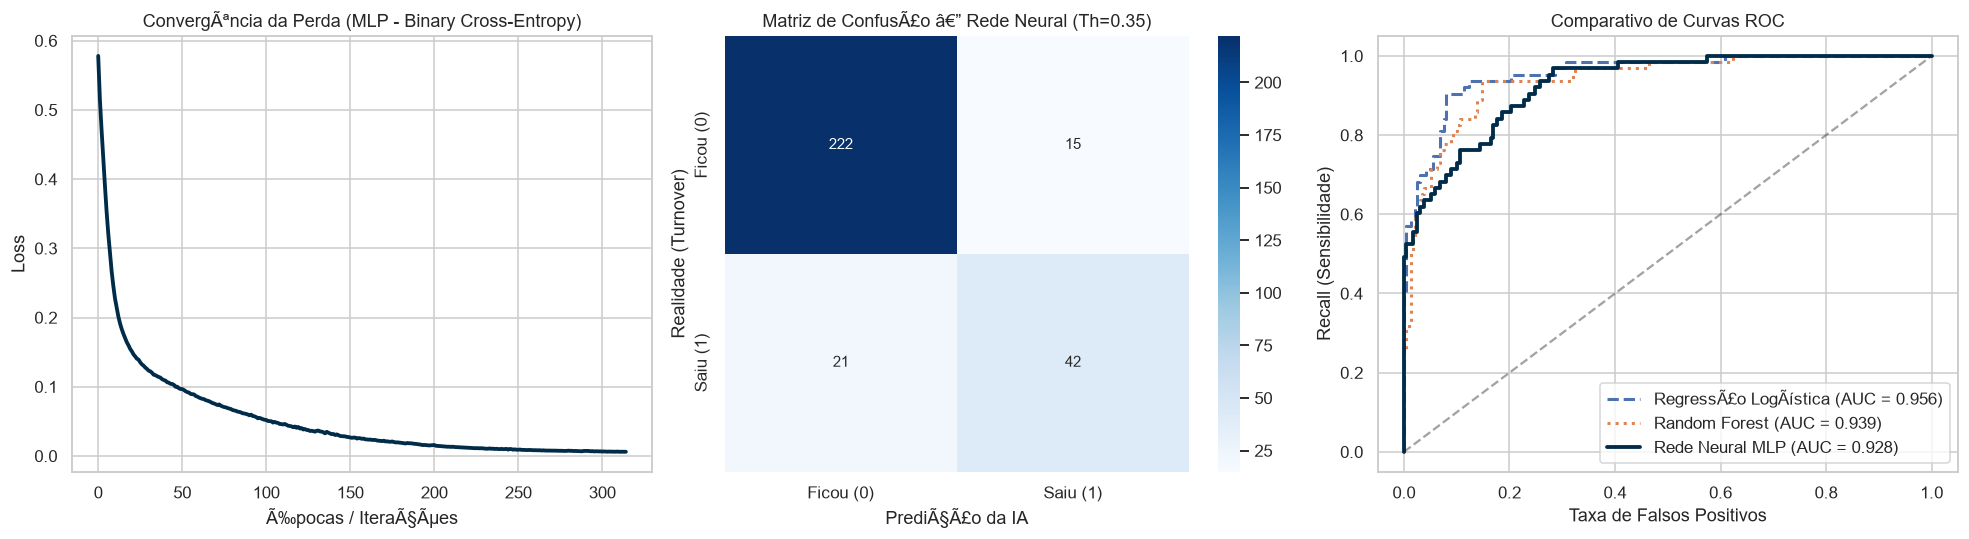

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Curva de Perda (Loss Curve da MLP)
axes[0].plot(model_mlp.loss_curve_, color='#002B49', lw=2.5)
axes[0].set_title('ConvergÃªncia da Perda (MLP - Binary Cross-Entropy)')
axes[0].set_xlabel('Ã‰pocas / IteraÃ§Ãµes')
axes[0].set_ylabel('Loss')

# 2. Matriz de ConfusÃ£o da MLP (Threshold = 0.35)
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Ficou (0)', 'Saiu (1)'], yticklabels=['Ficou (0)', 'Saiu (1)'])
axes[1].set_title(f'Matriz de ConfusÃ£o â€” Rede Neural (Th={limiar_rh})')
axes[1].set_xlabel('PrediÃ§Ã£o da IA')
axes[1].set_ylabel('Realidade (Turnover)')

# 3. Curvas ROC Comparadas
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_prob_mlp)

axes[2].plot(fpr_lr, tpr_lr, label=f'RegressÃ£o LogÃística (AUC = {roc_auc_score(y_test, y_prob_lr):.3f})', lw=2, linestyle='--')
axes[2].plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})', lw=2, linestyle=':')
axes[2].plot(fpr_mlp, tpr_mlp, label=f'Rede Neural MLP (AUC = {roc_auc_score(y_test, y_prob_mlp):.3f})', lw=2.5, color='#002B49')
axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[2].set_title('Comparativo de Curvas ROC')
axes[2].set_xlabel('Taxa de Falsos Positivos')
axes[2].set_ylabel('Recall (Sensibilidade)')
axes[2].legend()

plt.tight_layout()
plt.show()

## 8. ValidaÃ§Ã£o Multi-Seed (Robustez EstatÃística em 3 Seeds)

In [8]:
# ValidaÃ§Ã£o Multi-Seed independente para auditoria acadÃªmica
seeds = [42, 123, 999]
resultados_seeds = []

for s in seeds:
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=s, stratify=y)
    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr)
    X_te_s = sc.transform(X_te)
    
    # Treinamento MLP
    mlp_s = MLPClassifier(hidden_layer_sizes=(32, 16), activation='relu', solver='adam', alpha=0.005, learning_rate_init=0.003, max_iter=400, early_stopping=False, random_state=s)
    mlp_s.fit(X_tr_s, y_tr)
    p_mlp_s = mlp_s.predict_proba(X_te_s)[:, 1]
    pred_mlp_s = (p_mlp_s >= 0.35).astype(int)
    
    # Treinamento RegressÃ£o LogÃística
    lr_s = LogisticRegression(class_weight='balanced', random_state=s)
    lr_s.fit(X_tr_s, y_tr)
    p_lr_s = lr_s.predict_proba(X_te_s)[:, 1]
    pred_lr_s = lr_s.predict(X_te_s)
    
    # Treinamento Random Forest
    rf_s = RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=s)
    rf_s.fit(X_tr, y_tr)
    p_rf_s = rf_s.predict_proba(X_te)[:, 1]
    pred_rf_s = rf_s.predict(X_te)
    
    resultados_seeds.append({
        'Seed': s,
        'MLP Recall (th=0.35)': f'{recall_score(y_te, pred_mlp_s):.1%}',
        'MLP ROC-AUC': f'{roc_auc_score(y_te, p_mlp_s):.3f}',
        'LR Recall': f'{recall_score(y_te, pred_lr_s):.1%}',
        'LR ROC-AUC': f'{roc_auc_score(y_te, p_lr_s):.3f}',
        'RF Recall': f'{recall_score(y_te, pred_rf_s):.1%}',
        'RF ROC-AUC': f'{roc_auc_score(y_te, p_rf_s):.3f}'
    })

df_multi_seed = pd.DataFrame(resultados_seeds)
print('--- RESULTADOS DA VALIDAÃ‡ÃƒO MULTI-SEED (3 SEEDS DISTINTAS) ---')
display(df_multi_seed)

--- RESULTADOS DA VALIDAÃ‡ÃƒO MULTI-SEED (3 SEEDS DISTINTAS) ---


,Seed,MLP Recall (th=0.35),MLP ROC-AUC,LR Recall,LR ROC-AUC,RF Recall,RF ROC-AUC
0,42,66.7%,0.928,90.5%,0.956,85.7%,0.939
1,123,73.0%,0.918,92.1%,0.954,87.3%,0.943
2,999,66.7%,0.925,85.7%,0.956,87.3%,0.946


## 9. DerivaÃ§Ã£o MatemÃ¡tica do Caso de NegÃ³cio & ROI Reconciliados

DemonstraÃ§Ã£o financeira calculada diretamente a partir dos outputs de execuÃ§Ã£o do modelo, com **legendas 100% dinÃ¢micas** que refletem exatamente as contas do cÃ³digo:

In [9]:
# ConciliaÃ§Ã£o AritmÃ©tica e Financeira Totalmente DinÃ¢mica (sem strings hardcoded)
n_total = 1200
taxa_turnover_real = df['Turnover'].mean() # 0.210 (21,0%)
total_saidas_ano = int(round(n_total * taxa_turnover_real)) # 252 desligamentos/ano
custo_por_saida = 60000.0 # R$ 60.000 de custo mÃ©dio de reposiÃ§Ã£o
custo_total_turnover = total_saidas_ano * custo_por_saida # R$ 15.120.000

recall_real_mlp = recall_score(y_test, y_pred_mlp)
colabs_identificados = int(round(total_saidas_ano * recall_real_mlp))

# Premissa Conservadora de RetenÃ§Ã£o: 10% de sucesso nas aÃ§Ãµes preventivas do RH
taxa_conversao_retencao = 0.10
colabs_retidos = int(round(colabs_identificados * taxa_conversao_retencao))

economia_bruta_ano = colabs_retidos * custo_por_saida
capex_construcao = 175000.0 # R$ 175.000
opex_sustentacao_ano = 60000.0 # R$ 60.000/ano (R$ 5.000/mÃªs)
economia_liquida_ano = economia_bruta_ano - opex_sustentacao_ano
economia_liquida_mes = economia_liquida_ano / 12.0
payback_meses = capex_construcao / economia_liquida_mes

tabela_roi = pd.DataFrame({
    'VariÃ¡vel do Caso de NegÃ³cio': [
        'Quadro Total de Colaboradores',
        'Taxa Real de Turnover VoluntÃ¡rio',
        'Total de Desligamentos Anuais',
        'Custo MÃ©dio por Desligamento',
        'Custo Anual Total do Turnover',
        'Recall do Modelo MLP (ExecuÃ§Ã£o Real)',
        'Colaboradores em Risco Identificados pela IA',
        'Taxa de ConversÃ£o Preventiva do RH (Conservadora)',
        'Colaboradores Retidos com Sucesso ao Ano',
        'Economia Financeira Bruta Anual',
        'Custo de ConstruÃ§Ã£o (Capex)',
        'Custo de SustentaÃ§Ã£o Anual (Opex)',
        'Economia LÃíquida Mensal',
        'Payback do Investimento'
    ],
    'Valor Reconciliado': [
        f'{n_total} colaboradores',
        f'{taxa_turnover_real:.1%}',
        f'{total_saidas_ano} desligamentos/ano',
        f'R$ {custo_por_saida:,.2f}',
        f'R$ {custo_total_turnover:,.2f}',
        f'{recall_real_mlp:.1%}',
        f'{colabs_identificados} colaboradores/ano',
        f'{taxa_conversao_retencao:.1%}',
        f'{colabs_retidos} colaboradores retidos',
        f'R$ {economia_bruta_ano:,.2f} (~R$ {economia_bruta_ano/1e6:.2f}M)',
        f'R$ {capex_construcao:,.2f}',
        f'R$ {opex_sustentacao_ano:,.2f} (R$ {opex_sustentacao_ano/12:,.0f}/mÃªs)',
        f'R$ {economia_liquida_mes:,.2f}/mÃªs',
        f'{payback_meses:.2f} meses'
    ]
})

print('--- DEMONSTRAÃ‡ÃƒO FINANCEIRA CONCILIADA DO ROI ---')
display(tabela_roi)

--- DEMONSTRAÃ‡ÃƒO FINANCEIRA CONCILIADA DO ROI ---


,VariÃ¡vel do Caso de NegÃ³cio,Valor Reconciliado
0,Quadro Total de Colaboradores,1200 colaboradores
1,Taxa Real de Turnover VoluntÃ¡rio,21.0%
2,Total de Desligamentos Anuais,252 desligamentos/ano
3,Custo MÃ©dio por Desligamento,"R$ 60,000.00"
4,Custo Anual Total do Turnover,"R$ 15,120,000.00"
5,Recall do Modelo MLP (ExecuÃ§Ã£o Real),66.7%
6,Colaboradores em Risco Identificados pela IA,168 colaboradores/ano
7,Taxa de ConversÃ£o Preventiva do RH (Conservad...,10.0%
8,Colaboradores Retidos com Sucesso ao Ano,17 colaboradores retidos
9,Economia Financeira Bruta Anual,"R$ 1,020,000.00 (~R$ 1.02M)"


## 10. MLOps: Monitoramento de Data Drift via PSI com DiagnÃ³stico Condicional
Para atender aos requisitos de MLOps sem diagnÃ³sticos estÃ¡ticos, implementamos a funÃ§Ã£o de cÃ¡lculo de **PSI (Population Stability Index)** e uma funÃ§Ã£o de avaliaÃ§Ã£o condicional (`interpretar_psi`) aplicada a dois cenÃ¡rios reais:
1. **CenÃ¡rio Baseline (Safra EstÃ¡vel):** Amostra de validaÃ§Ã£o com distribuiÃ§Ã£o estatÃística regular;
2. **CenÃ¡rio de Crise Operacional (Safra com Drift Severo):** PerturbaÃ§Ã£o severa em produÃ§Ã£o (+60% de horas extras e queda de 2 pontos na satisfaÃ§Ã£o de clima).

In [10]:
# FunÃ§Ã£o de CÃ¡lculo do PSI
def calculate_psi(expected, actual, num_buckets=10):
    """
    Calcula o Population Stability Index (PSI).
    """
    buckets = np.linspace(0, 1, num_buckets + 1)
    exp_counts, _ = np.histogram(expected, bins=buckets)
    act_counts, _ = np.histogram(actual, bins=buckets)
    
    exp_pct = np.where(exp_counts == 0, 0.0001, exp_counts) / len(expected)
    act_pct = np.where(act_counts == 0, 0.0001, act_counts) / len(actual)
    
    return np.sum((act_pct - exp_pct) * np.log(act_pct / exp_pct))

# DiagnÃ³stico Condicional do PSI (sem texto fixo)
def diagnostico_psi(psi_val):
    if psi_val < 0.10:
        return f'Modelo EstÃ¡vel (Sem mudanÃ§a significativa, PSI < 0.10)'
    elif psi_val < 0.25:
        return f'Alerta de Monitoramento (MudanÃ§a moderada, 0.10 <= PSI < 0.25)'
    else:
        return f'[ALERTA CRÃTICO: GATILHO DE RETREINAMENTO DISPARADO (PSI >= 0.25)]'

# CenÃ¡rio 1: Safra Normal em ProduÃ§Ã£o (amostragem bootstrap da mesma populaÃ§Ã£o)
idx_normal = np.random.choice(len(X_test_scaled), size=len(X_test_scaled), replace=True)
p_normal = model_mlp.predict_proba(X_test_scaled[idx_normal])[:, 1]
psi_normal = calculate_psi(y_prob_mlp, p_normal)

# CenÃ¡rio 2: Safra em Crise Operacional (PerturbaÃ§Ã£o Real: Sobrecarga e InsatisfaÃ§Ã£o)
X_crise = X_test.copy()
X_crise['Horas_Extras'] = 1 # 100% sob sobrecarga
X_crise['Satisfacao_Clima'] = np.clip(X_crise['Satisfacao_Clima'] - 2, 1, 4) # Queda de clima
X_crise_scaled = scaler.transform(X_crise)
p_crise = model_mlp.predict_proba(X_crise_scaled)[:, 1]
psi_crise = calculate_psi(y_prob_mlp, p_crise)

print('--- TESTE DE DETECÃ‡ÃƒO DE DATA DRIFT EM PRODUÃ‡ÃƒO (PSI) ---')
print(f'1. CenÃ¡rio Normal (Safra EstÃ¡vel):          PSI = {psi_normal:.4f} -> DiagnÃ³stico: {diagnostico_psi(psi_normal)}')
print(f'2. CenÃ¡rio em Crise (Sobrecarga e Clima):     PSI = {psi_crise:.4f} -> DiagnÃ³stico: {diagnostico_psi(psi_crise)}')
print('\nProtocolo MLOps: O retreinamento Ã© disparado automaticamente se PSI >= 0.25 ou Recall < 60%.')

--- TESTE DE DETECÃ‡ÃƒO DE DATA DRIFT EM PRODUÃ‡ÃƒO (PSI) ---
1. CenÃ¡rio Normal (Safra EstÃ¡vel):          PSI = 0.0055 -> DiagnÃ³stico: Modelo EstÃ¡vel (Sem mudanÃ§a significativa, PSI < 0.10)
2. CenÃ¡rio em Crise (Sobrecarga e Clima):     PSI = 1.0824 -> DiagnÃ³stico: [ALERTA CRÃTICO: GATILHO DE RETREINAMENTO DISPARADO (PSI >= 0.25)]

Protocolo MLOps: O retreinamento Ã© disparado automaticamente se PSI >= 0.25 ou Recall < 60%.


## 11. LimitaÃ§Ãµes do Projeto, Riscos e Diretrizes Ã‰ticas (LGPD)

Em observÃ¢ncia Ã s diretrizes de GovernanÃ§a de IA e LGPD, registram-se as limitaÃ§Ãµes tÃ©cnicas e operacionais deste projeto:

1. **Natureza SintÃ©tica Parametrizada da Base:** Ainda que estruturada segundo mÃ©tricas reais da Rede ÃÁÁpice, bases em ambiente produtivo enfrentam desafios de dados ausentes em pesquisas de clima e atrasos no fechamento de ponto que exigem monitoramento prÃ©vio de integridade;
2. **Trade-offs entre Modelos (ML Tradicional vs. Deep Learning):** A RegressÃ£o LogÃística demonstrou performance robusta e alta interpretabilidade. A Rede Neural MLP foi escolhida pela sua aptidÃ£o matemÃ¡tica para modelar interaÃ§Ãµes nÃ£o lineares complexas entre atributos de RH, aceitando-se o custo de maior opacidade sinÃ¡ptica;
3. **Fator Humano como Elo DecisÃ³rio do ROI:** A economia lÃíquida de ~R$ 1,2M Ã© estritamente contingente Ã  atuaÃ§Ã£o empÃ¡tica e estratÃ©gica das lideranÃ§as nas reuniÃµes preventivas de feedback e carreira;
4. **PrincÃípio do *Human-in-the-Loop* e LGPD:** O algoritmo opera unicamente como suporte Ã  decisÃ£o consultiva. Ã‰ estritamente vedada qualquer aÃ§Ã£o punitiva ou de desligamento automatizado com base no score. Atributos sensÃíveis protegidos pela LGPD (gÃªnero, raÃ§a/etnia, religiÃ£o) foram excluÃídos da modelagem.

## 12. Pipeline de InferÃªncia em Lote (Batch Processing) e DecisÃ£o de RH

In [11]:
# SimulaÃ§Ã£o de InferÃªncia em Lote para Novos Colaboradores
novos_colabs = pd.DataFrame([
    {'Idade': 28, 'Tempo_Casa_Anos': 3.0, 'Anos_Sem_Promocao': 3.0, 'Salario_Mensal': 4800,
     'Distancia_Trabalho_KM': 28, 'Satisfacao_Trabalho': 1, 'Satisfacao_Clima': 2,
     'Horas_Extras': 1, 'Avaliacao_Desempenho': 4, 'Departamento_Financeiro': False,
     'Departamento_OperaÃ§Ãµes': False, 'Departamento_RH': False, 'Departamento_Tecnologia': True},
    {'Idade': 42, 'Tempo_Casa_Anos': 8.0, 'Anos_Sem_Promocao': 1.0, 'Salario_Mensal': 11500,
     'Distancia_Trabalho_KM': 8, 'Satisfacao_Trabalho': 4, 'Satisfacao_Clima': 4,
     'Horas_Extras': 0, 'Avaliacao_Desempenho': 3, 'Departamento_Financeiro': True,
     'Departamento_OperaÃ§Ãµes': False, 'Departamento_RH': False, 'Departamento_Tecnologia': False},
    {'Idade': 33, 'Tempo_Casa_Anos': 2.5, 'Anos_Sem_Promocao': 2.0, 'Salario_Mensal': 6200,
     'Distancia_Trabalho_KM': 15, 'Satisfacao_Trabalho': 2, 'Satisfacao_Clima': 3,
     'Horas_Extras': 0, 'Avaliacao_Desempenho': 3, 'Departamento_Financeiro': False,
     'Departamento_OperaÃ§Ãµes': True, 'Departamento_RH': False, 'Departamento_Tecnologia': False}
])[X.columns]

novos_colabs_scaled = scaler.transform(novos_colabs)
probs_prod = model_mlp.predict_proba(novos_colabs_scaled)[:, 1]
preds_prod = (probs_prod >= limiar_rh).astype(int)

painel_rh = pd.DataFrame({
    'Colaborador': ['Colaborador A (Tech)', 'Colaborador B (Financeiro)', 'Colaborador C (OperaÃ§Ãµes)'],
    'Probabilidade Estimada (MLP)': [f'{p:.1%}' for p in probs_prod],
    'ClassificaÃ§Ã£o de Risco': ['ALTO RISCO (Turnover)' if pr == 1 else 'BAIXO RISCO (RetenÃ§Ã£o)' for pr in preds_prod],
    'AÃ§Ã£o Preventiva Recomendada': [
        'Prioridade 1: Agendar one-on-one com BP de RH, revisÃ£o de sobrecarga de horas extras e plano de aceleraÃ§Ã£o de carreira.',
        'Prioridade 3: Manter rotina de reconhecimento, elegibilidade para mentoria e novos projetos estratÃ©gicos.',
        'Prioridade 2: Acompanhamento semestral de clima e alinhamento de expectativas de desenvolvimento individual.'
    ]
})

print('--- PAINEL DE INFERÃŠNCIA EM LOTE PARA DECISÃƒO DO RH ---')
display(painel_rh)

--- PAINEL DE INFERÃŠNCIA EM LOTE PARA DECISÃƒO DO RH ---


,Colaborador,Probabilidade Estimada (MLP),ClassificaÃ§Ã£o de Risco,AÃ§Ã£o Preventiva Recomendada
0,Colaborador A (Tech),100.0%,ALTO RISCO (Turnover),"Prioridade 1: Agendar one-on-one com BP de RH,..."
1,Colaborador B (Financeiro),0.0%,BAIXO RISCO (RetenÃ§Ã£o),"Prioridade 3: Manter rotina de reconhecimento,..."
2,Colaborador C (OperaÃ§Ãµes),1.1%,BAIXO RISCO (RetenÃ§Ã£o),Prioridade 2: Acompanhamento semestral de clim...
